# Задача 2. Статистические модели (statsforecast)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsforecast import StatsForecast
from statsforecast.models import (
    ARIMA,
    AutoARIMA,
    AutoETS,
    AutoTheta,
    Naive,
    SeasonalNaive,
    Theta,
)
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.config import FORECAST_HORIZON, SEASON
from src.metrics import evaluate, metrics_table
from src.stats import cross_validate_models, cv_by_window, cv_summary, in_sample_fitted, with_residuals

H = FORECAST_HORIZON
CV_H = 24
N_WINDOWS = 5
CV_STEP = 24

In [2]:
train_df = pd.read_parquet('__output__/train.parquet')
test_df = pd.read_parquet('__output__/test.parquet')

In [3]:
def df2data(df: pd.DataFrame):
    return pd.DataFrame({
        'unique_id': df['unique_id'].copy(),
        'ds': df.index.values.copy(),
        'y': df['AC_POWER'].copy()
    })

In [4]:
train_data = df2data(train_df)
test_data = df2data(test_df)

# Naive

In [5]:
naive_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON)
]

sf_naive = StatsForecast(
    models=naive_models,
    freq='h'
)

In [6]:
sf_naive.fit(train_data)

StatsForecast(models=[Naive,SeasonalNaive])

In [7]:
naive_forecasts = sf_naive.predict(h=H)

# Авто-модели

In [8]:
auto_models = [
    AutoARIMA(season_length=SEASON),
    AutoETS(season_length=SEASON),
    AutoTheta(season_length=SEASON)
]

auto_sf = StatsForecast(
    models=auto_models,
    freq='h',
    n_jobs=4
)

In [9]:
auto_sf.fit(train_data)

StatsForecast(models=[AutoARIMA,AutoETS,AutoTheta])

In [10]:
auto_forecasts = auto_sf.predict(h=H)

## Ручная настройка (ARIMA, Theta, CES)

In [11]:
manual_models = [
    ARIMA(
        order=(2, 1, 2),
        season_length=SEASON
    ),
    Theta(
        season_length=SEASON,
        decomposition_type='additive'
    )
]

manual_sf = StatsForecast(models=manual_models, freq='h', n_jobs=-1)

In [12]:
manual_sf.fit(train_data)

StatsForecast(models=[ARIMA,Theta])

In [13]:
manual_forecasts = manual_sf.predict(h=H)

# Test

In [14]:
def print_metrics(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    eval_rows = []
    for m in models:
        m_name = m.alias

        metrics = evaluate(data['y'], data[m_name])
        metrics['model'] = m_name
        eval_rows.append(metrics)

    results_auto = metrics_table(eval_rows)

    return results_auto

In [15]:
# Naive

print_metrics(
    test_data,
    naive_forecasts,
    naive_models
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
SeasonalNaive,5860.657587,10989.593847,28.648802,18.980735
Naive,19887.051661,32577.206719,54.166667,108.333333


In [16]:
# Auto

print_metrics(
    test_data,
    auto_forecasts,
    auto_models
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
AutoETS,5278.103728,8704.432062,6.741455e+10,109.018953
AutoTheta,4918.272784,9048.667166,3.630221e+09,106.743924
AutoARIMA,5246.136296,9961.708525,2.654243e+09,62.377402


In [17]:
# Manual

print_metrics(
    test_data,
    manual_forecasts,
    manual_models
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
Theta,4912.425216,9040.475607,3.886466e+09,106.691330
ARIMA,17940.603322,25525.553093,3.490383e+11,162.851647


In [18]:
def plot_forecast(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    fig, axes = plt.subplots(len(models), 1, figsize=(10, 2*len(models)))

    for ax, m in zip(axes, models):
        m_name = m.alias

        ax.plot(
            data['ds'],
            data['y'],
            label='True'
        )

        ax.plot(
            forecast['ds'],
            forecast[m_name],
            label='Predict'
        )

        ax.legend()
        ax.set_title(f'Model - {m_name}')

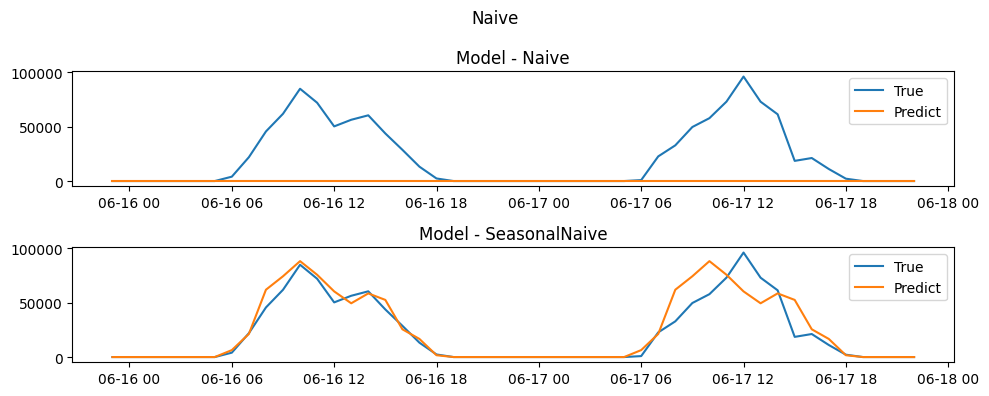

In [19]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    naive_forecasts[naive_forecasts['unique_id'] == '1'],
    naive_models
)

plt.suptitle('Naive')

plt.tight_layout()
plt.show()

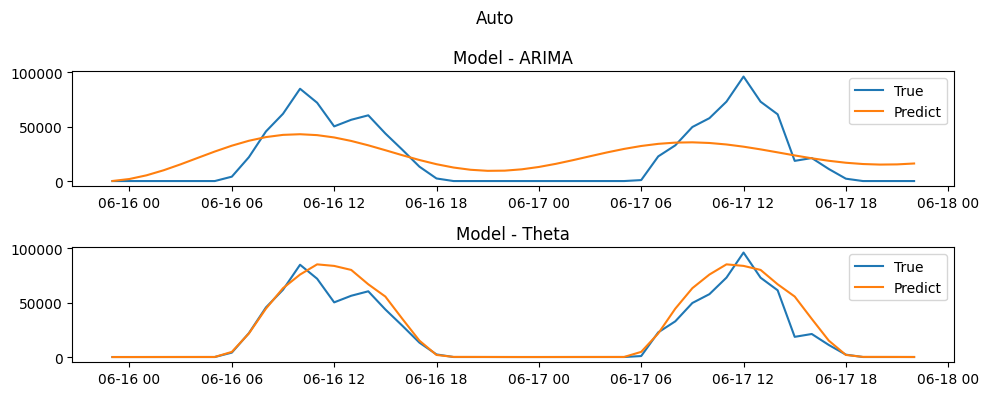

In [20]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    manual_forecasts[manual_forecasts['unique_id'] == '1'],
    manual_models
)

plt.suptitle('Auto')

plt.tight_layout()
plt.show()

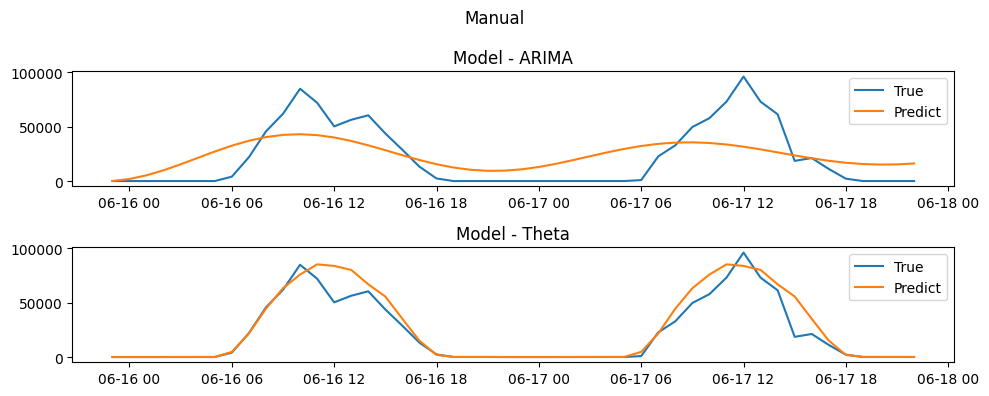

In [21]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    manual_forecasts[manual_forecasts['unique_id'] == '1'],
    manual_models
)

plt.suptitle('Manual')

plt.tight_layout()
plt.show()

## Анализ остатков

In-sample диагностика для моделей с лучшим RMSE на hold-out: проверяем, что остатки не имеют автокорреляции (Ljung–Box) и приближаются к нормальности (Q–Q plot). Для солнечной выработки ночные нули дают асимметрию — это ожидаемо для аддитивных моделей.

Лучшая auto-модель на hold-out: AutoETS


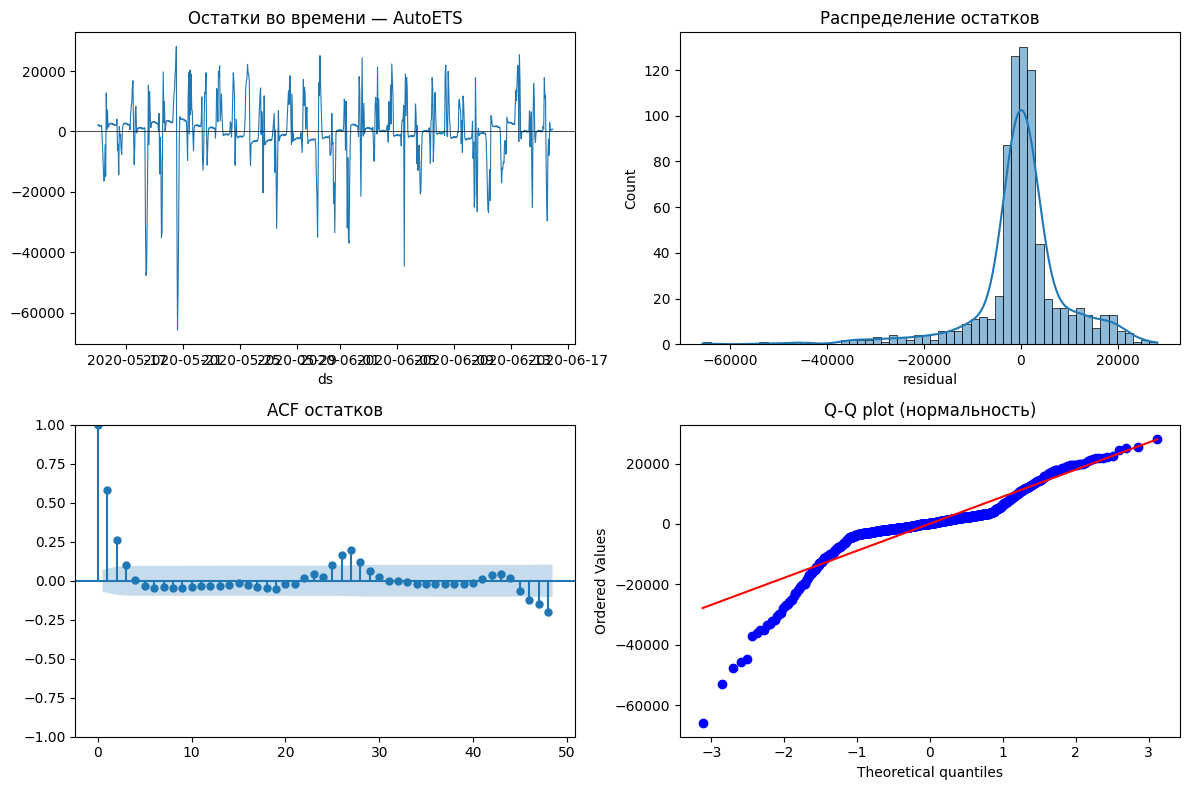

Ljung–Box (AutoETS):


,lb_stat,lb_pvalue
24,340.008563,1.351593e-57
48,489.763731,1.679960e-74


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
AutoETS,767.0,93.33,9737.96,-65688.12,-2174.38,233.66,2942.81,28111.41


In [22]:
def plot_residual_diagnostics(residual_df: pd.DataFrame, model_name: str):
    '''Графики остатков: временной ряд, гистограмма, ACF, Q-Q.'''
    res = residual_df['residual'].dropna()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(residual_df['ds'], res, linewidth=0.8)
    axes[0, 0].axhline(0, color='k', linewidth=0.5)
    axes[0, 0].set_title(f'Остатки во времени — {model_name}')
    axes[0, 0].set_xlabel('ds')

    sns.histplot(res, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Распределение остатков')

    plot_acf(res, lags=48, ax=axes[1, 0])
    axes[1, 0].set_title('ACF остатков')

    stats.probplot(res, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q plot (нормальность)')

    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(res, lags=[24, 48], return_df=True)
    print(f'Ljung–Box ({model_name}):')
    display(lb)


# Лучшая auto-модель по hold-out
holdout_ranking = print_metrics(test_data, auto_forecasts, auto_models)
best_auto_name = holdout_ranking.index[0]
print(f'Лучшая auto-модель на hold-out: {best_auto_name}')

residual_candidates = {
    m.alias: m
    for m in auto_models
    if m.alias in {best_auto_name, 'SeasonalNaive'}
}

residual_data = train_data[train_data['unique_id'] == '1']
residual_rows = []

for name, model in residual_candidates.items():
    fitted = in_sample_fitted(residual_data, [model])
    res_df = with_residuals(fitted, name)
    residual_rows.append(res_df)
    plot_residual_diagnostics(res_df, name)

residual_summary = pd.concat(residual_rows, ignore_index=True)
residual_summary.groupby('model')['residual'].describe().round(2)

## Backtest

Rolling cross-validation (`statsforecast.cross_validation`): горизонт **24 ч**, **5 окон**, шаг **24 ч** — оценка стабильности качества до финального hold-out на 48 ч.

In [ ]:
cv_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON),
    AutoETS(season_length=SEASON),
    AutoTheta(season_length=SEASON),
    AutoARIMA(season_length=SEASON),
]
cv_model_names = [m.alias for m in cv_models]

cv_data = train_data[train_data['unique_id'] == '1']
cv_results = cross_validate_models(
    cv_data,
    cv_models,
    h=CV_H,
    n_windows=N_WINDOWS,
    step_size=CV_STEP,
)

print(f'Cross-validation: h={CV_H}, n_windows={N_WINDOWS}, step={CV_STEP}')
cv_overall = cv_summary(cv_results, cv_model_names)
display(cv_overall)

cv_window_metrics = cv_by_window(cv_results, cv_model_names)
cv_pivot = cv_window_metrics.pivot(index='cutoff', columns='model', values='RMSE')
display(cv_pivot.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for name in cv_model_names:
    subset = cv_window_metrics[cv_window_metrics['model'] == name]
    ax.plot(subset['cutoff'], subset['RMSE'], marker='o', label=name)
ax.set_title('RMSE по окнам cross-validation')
ax.set_xlabel('cutoff (конец train-окна)')
ax.set_ylabel('RMSE')
ax.legend(loc='best', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_cv_name = cv_overall.index[0]
print(f'Лучшая модель по backtest (средний RMSE): {best_cv_name}')